<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [159]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect, text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google.colab import userdata

engine = create_engine(userdata.get("NEON_DATABASE_URL"))
extract_query ="""
SELECT "CustomerID",
    "TotalRevenue",
    "Tenure",
    "Recency",
    "ProductDiversity",
    "Frequency"
FROM v_customer_metrics
"""

df = pd.read_sql(text(extract_query), con = engine)
print("Preview of Customer Segmentation Features")
df.head()

Preview of Customer Segmentation Features


,CustomerID,TotalRevenue,Tenure,Recency,ProductDiversity,Frequency
0,12346.0,77183.60,0,325,1,1
1,12347.0,2790.86,238,129,82,5
2,12348.0,1487.24,110,248,22,3
3,12350.0,334.40,0,310,17,1
4,12352.0,1561.81,34,262,26,4


/tmp/ipykernel_506/170162039.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


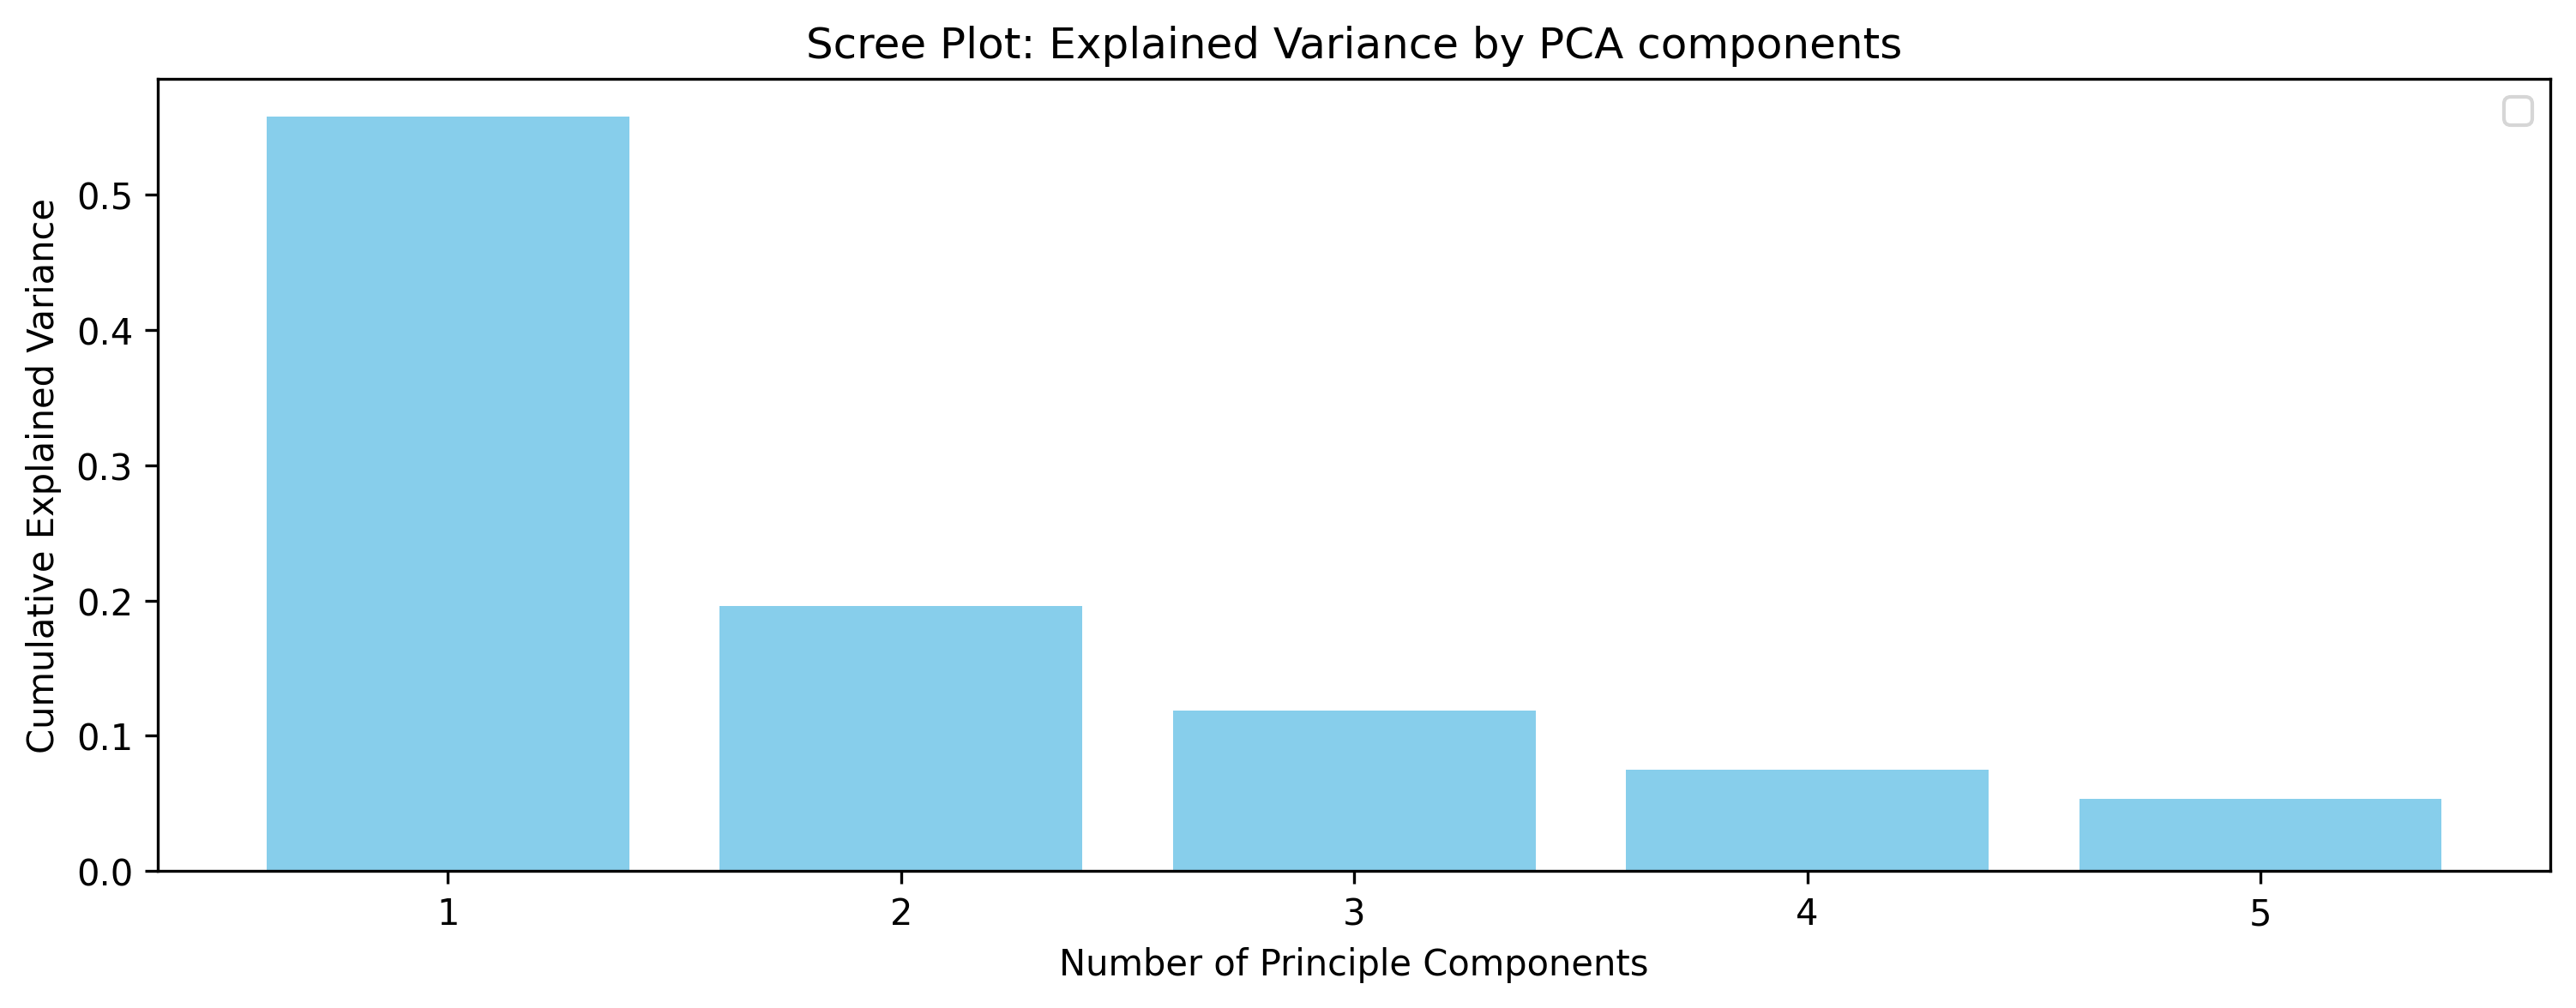

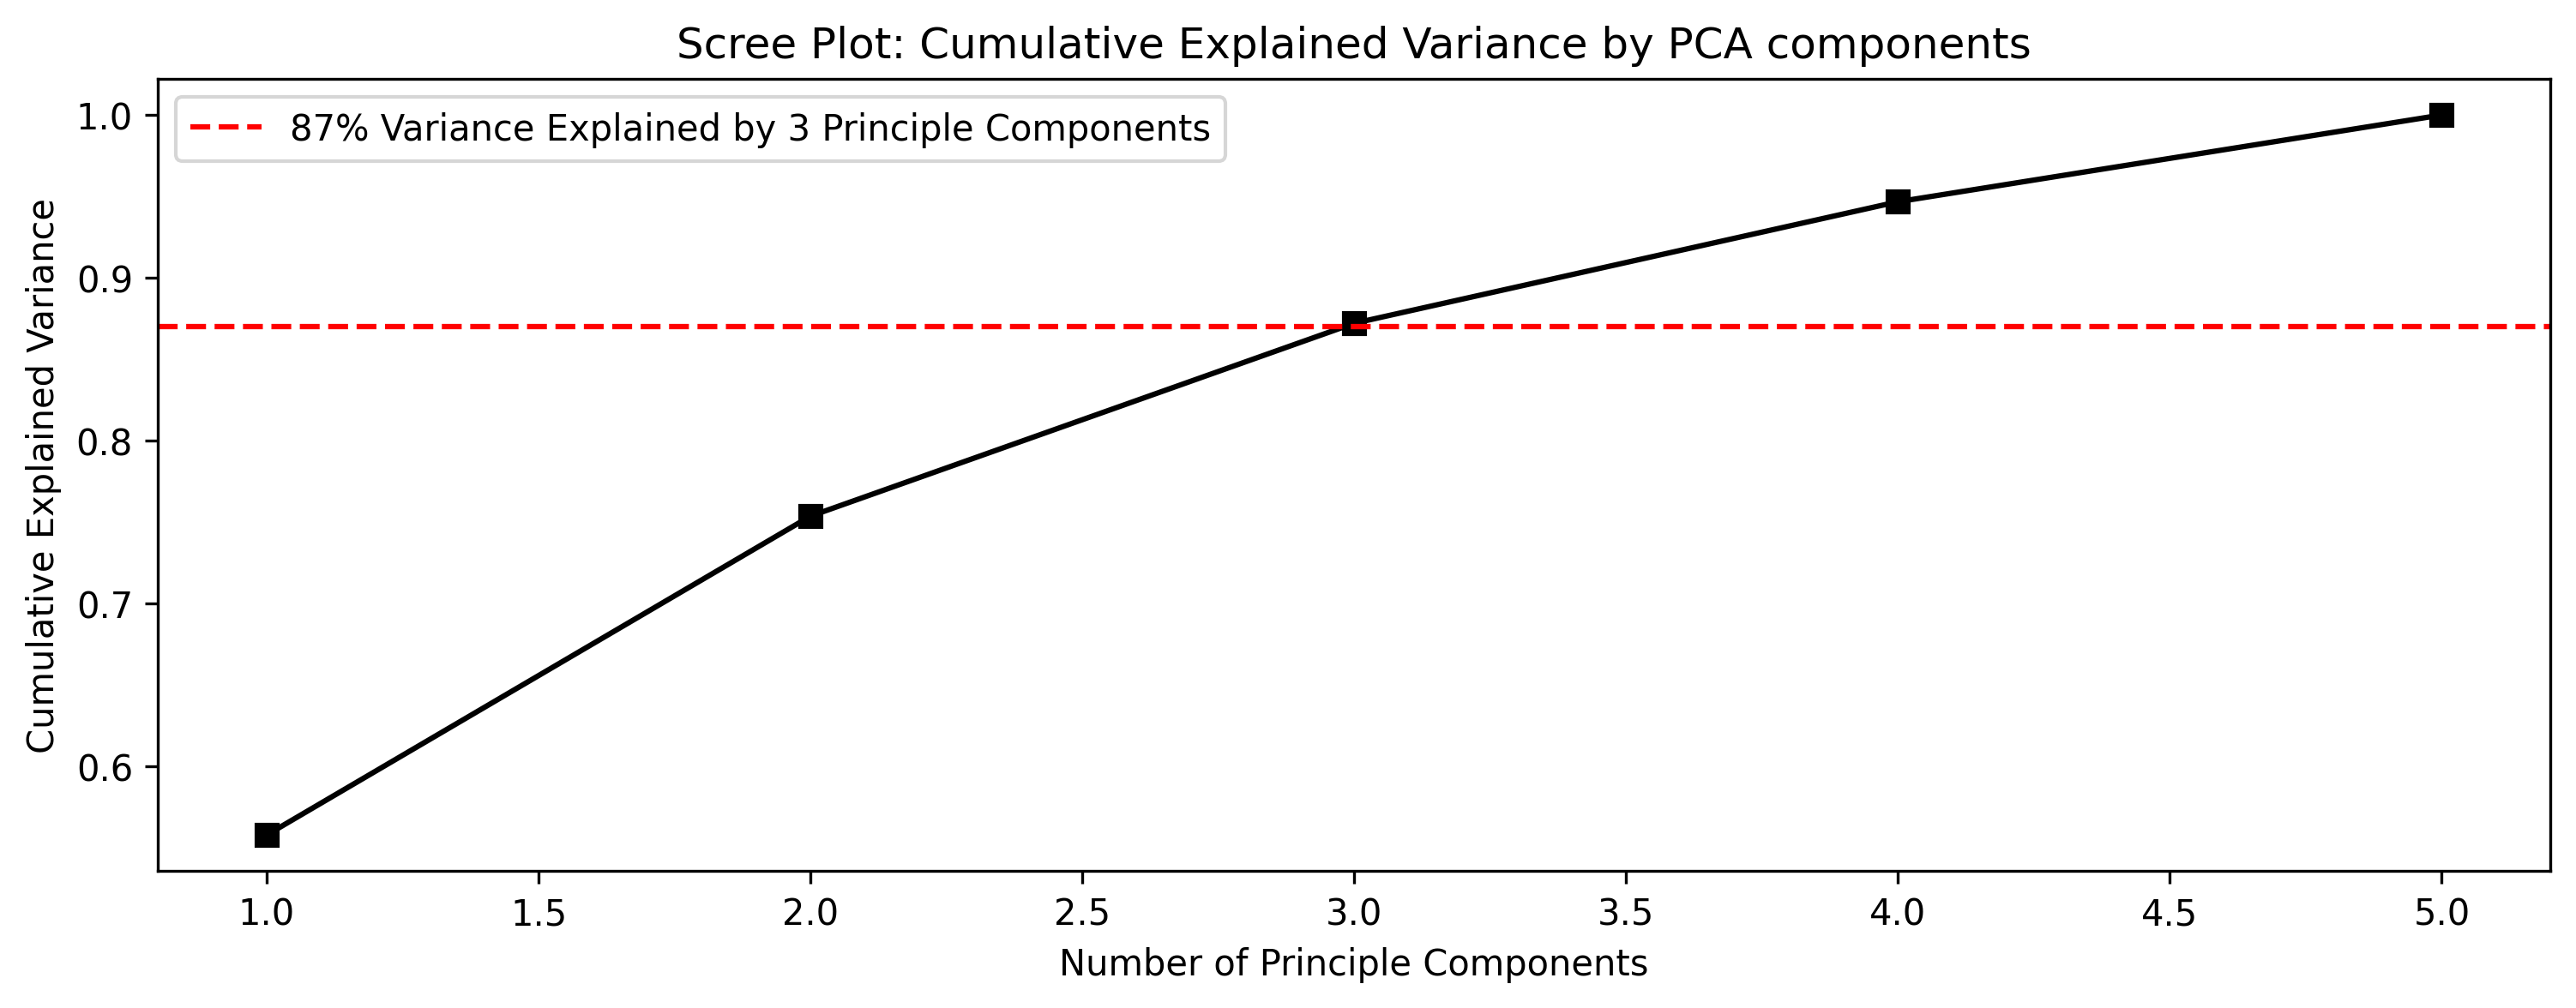

In [160]:
X = df.drop("CustomerID", axis = 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
x_axis = range(1, len(cumulative_variance) +1)

plt.figure(figsize = (12,4), dpi = 300)
plt.bar(x_axis, explained_variance, color = "skyblue")
plt.title("Scree Plot: Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(x_axis, cumulative_variance, marker = 's', color = 'black')
plt.axhline(y = 0.87, linestyle = '--', color = 'red', label = "87% Variance Explained by 3 Principle Components")
plt.title("Scree Plot: Cumulative Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

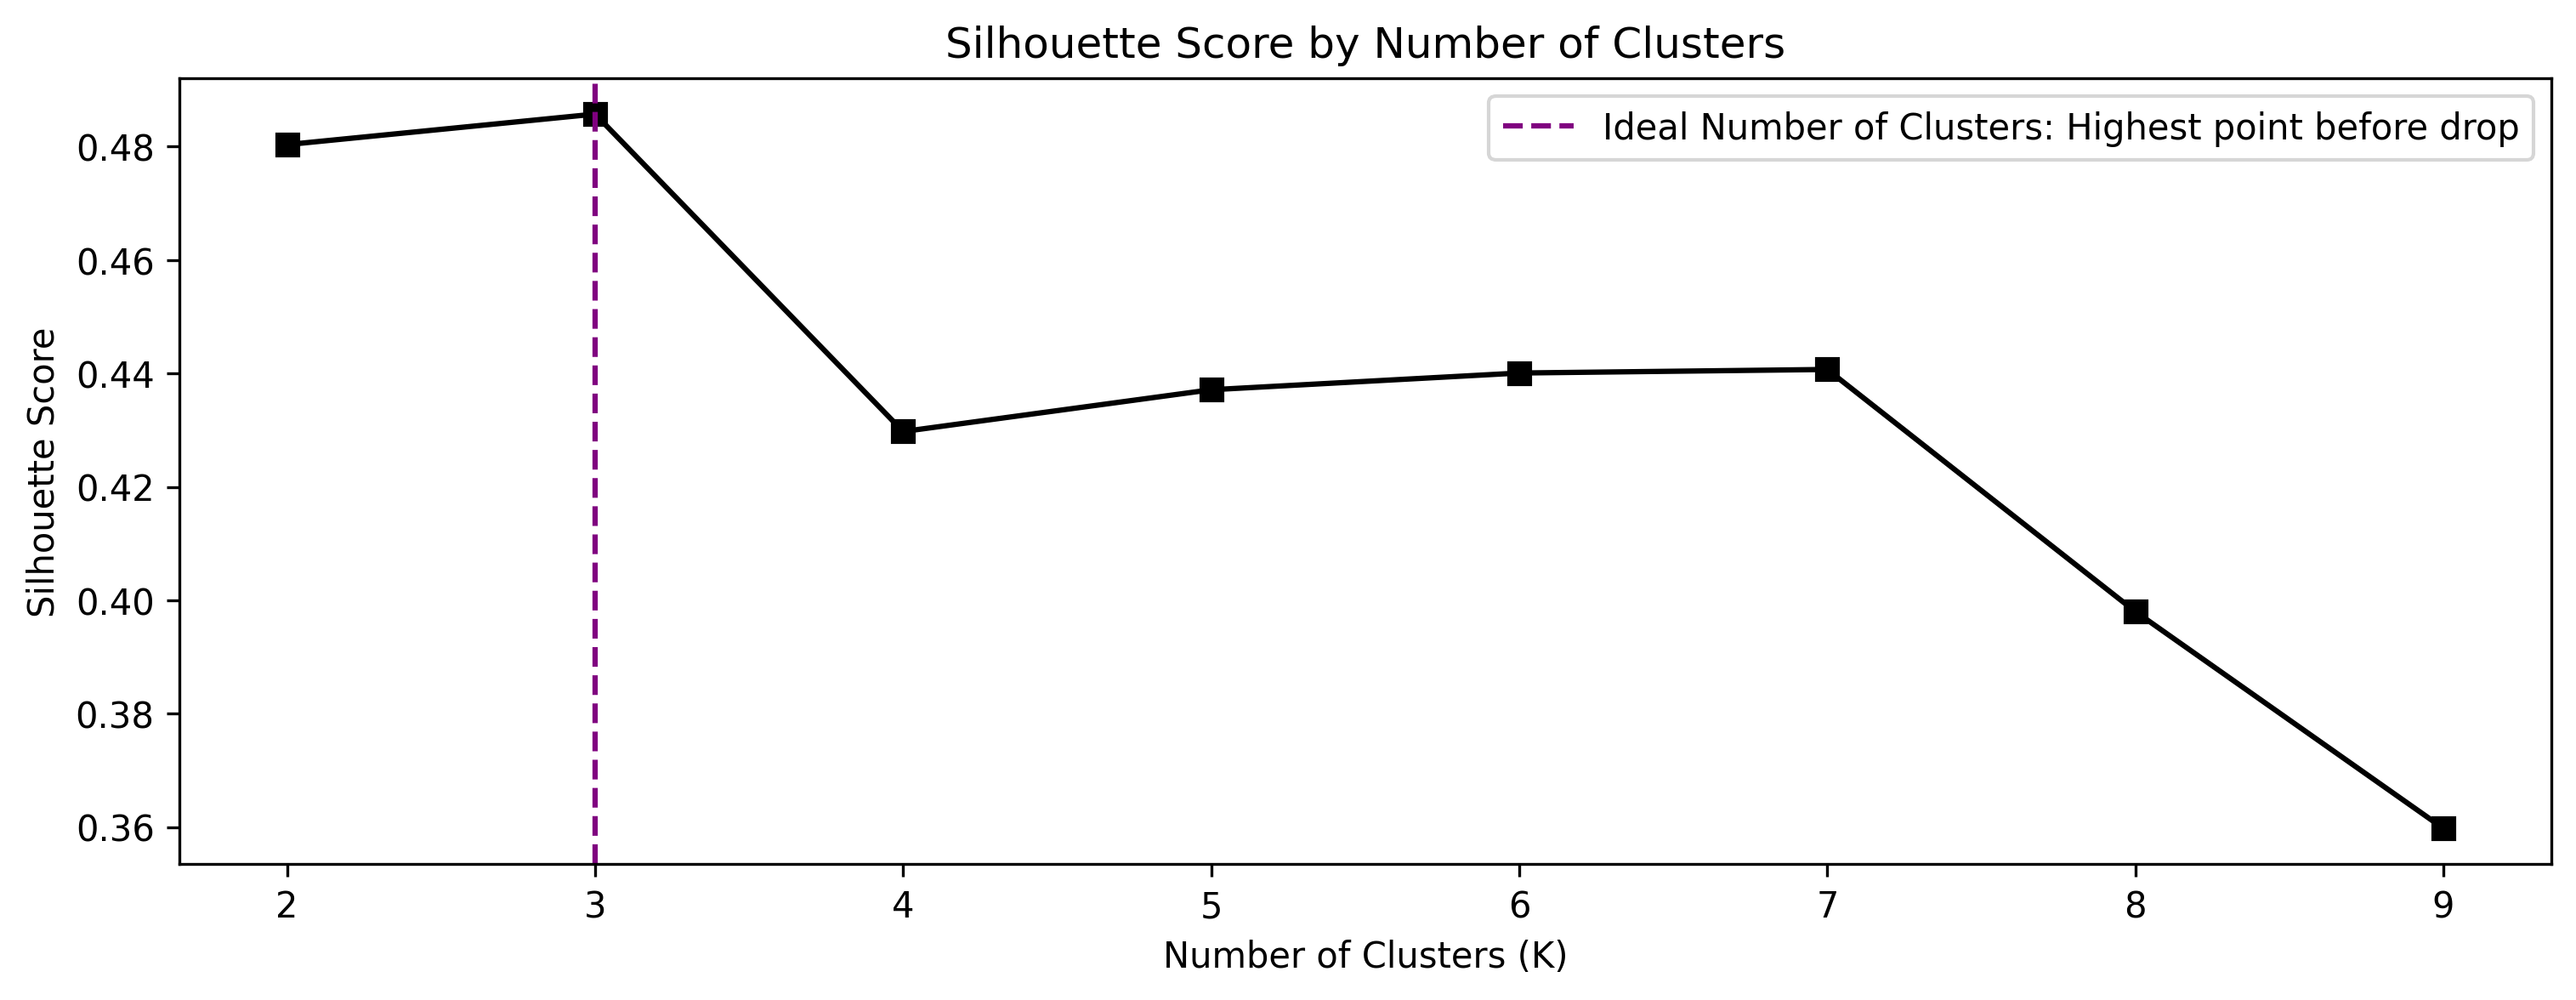

In [161]:
pca_components = 3

pca = PCA(n_components = pca_components)

X_pca = pca.fit_transform(X_scaled)

k_range = range(2,10)

s_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    k_labels = kmeans.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, k_labels)
    s_scores.append(sil_score)

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(k_range, s_scores, marker = 's', color = "black")
plt.axvline(x = 3, color = 'purple', linestyle = '--', label = "Ideal Number of Clusters: Highest point before drop")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

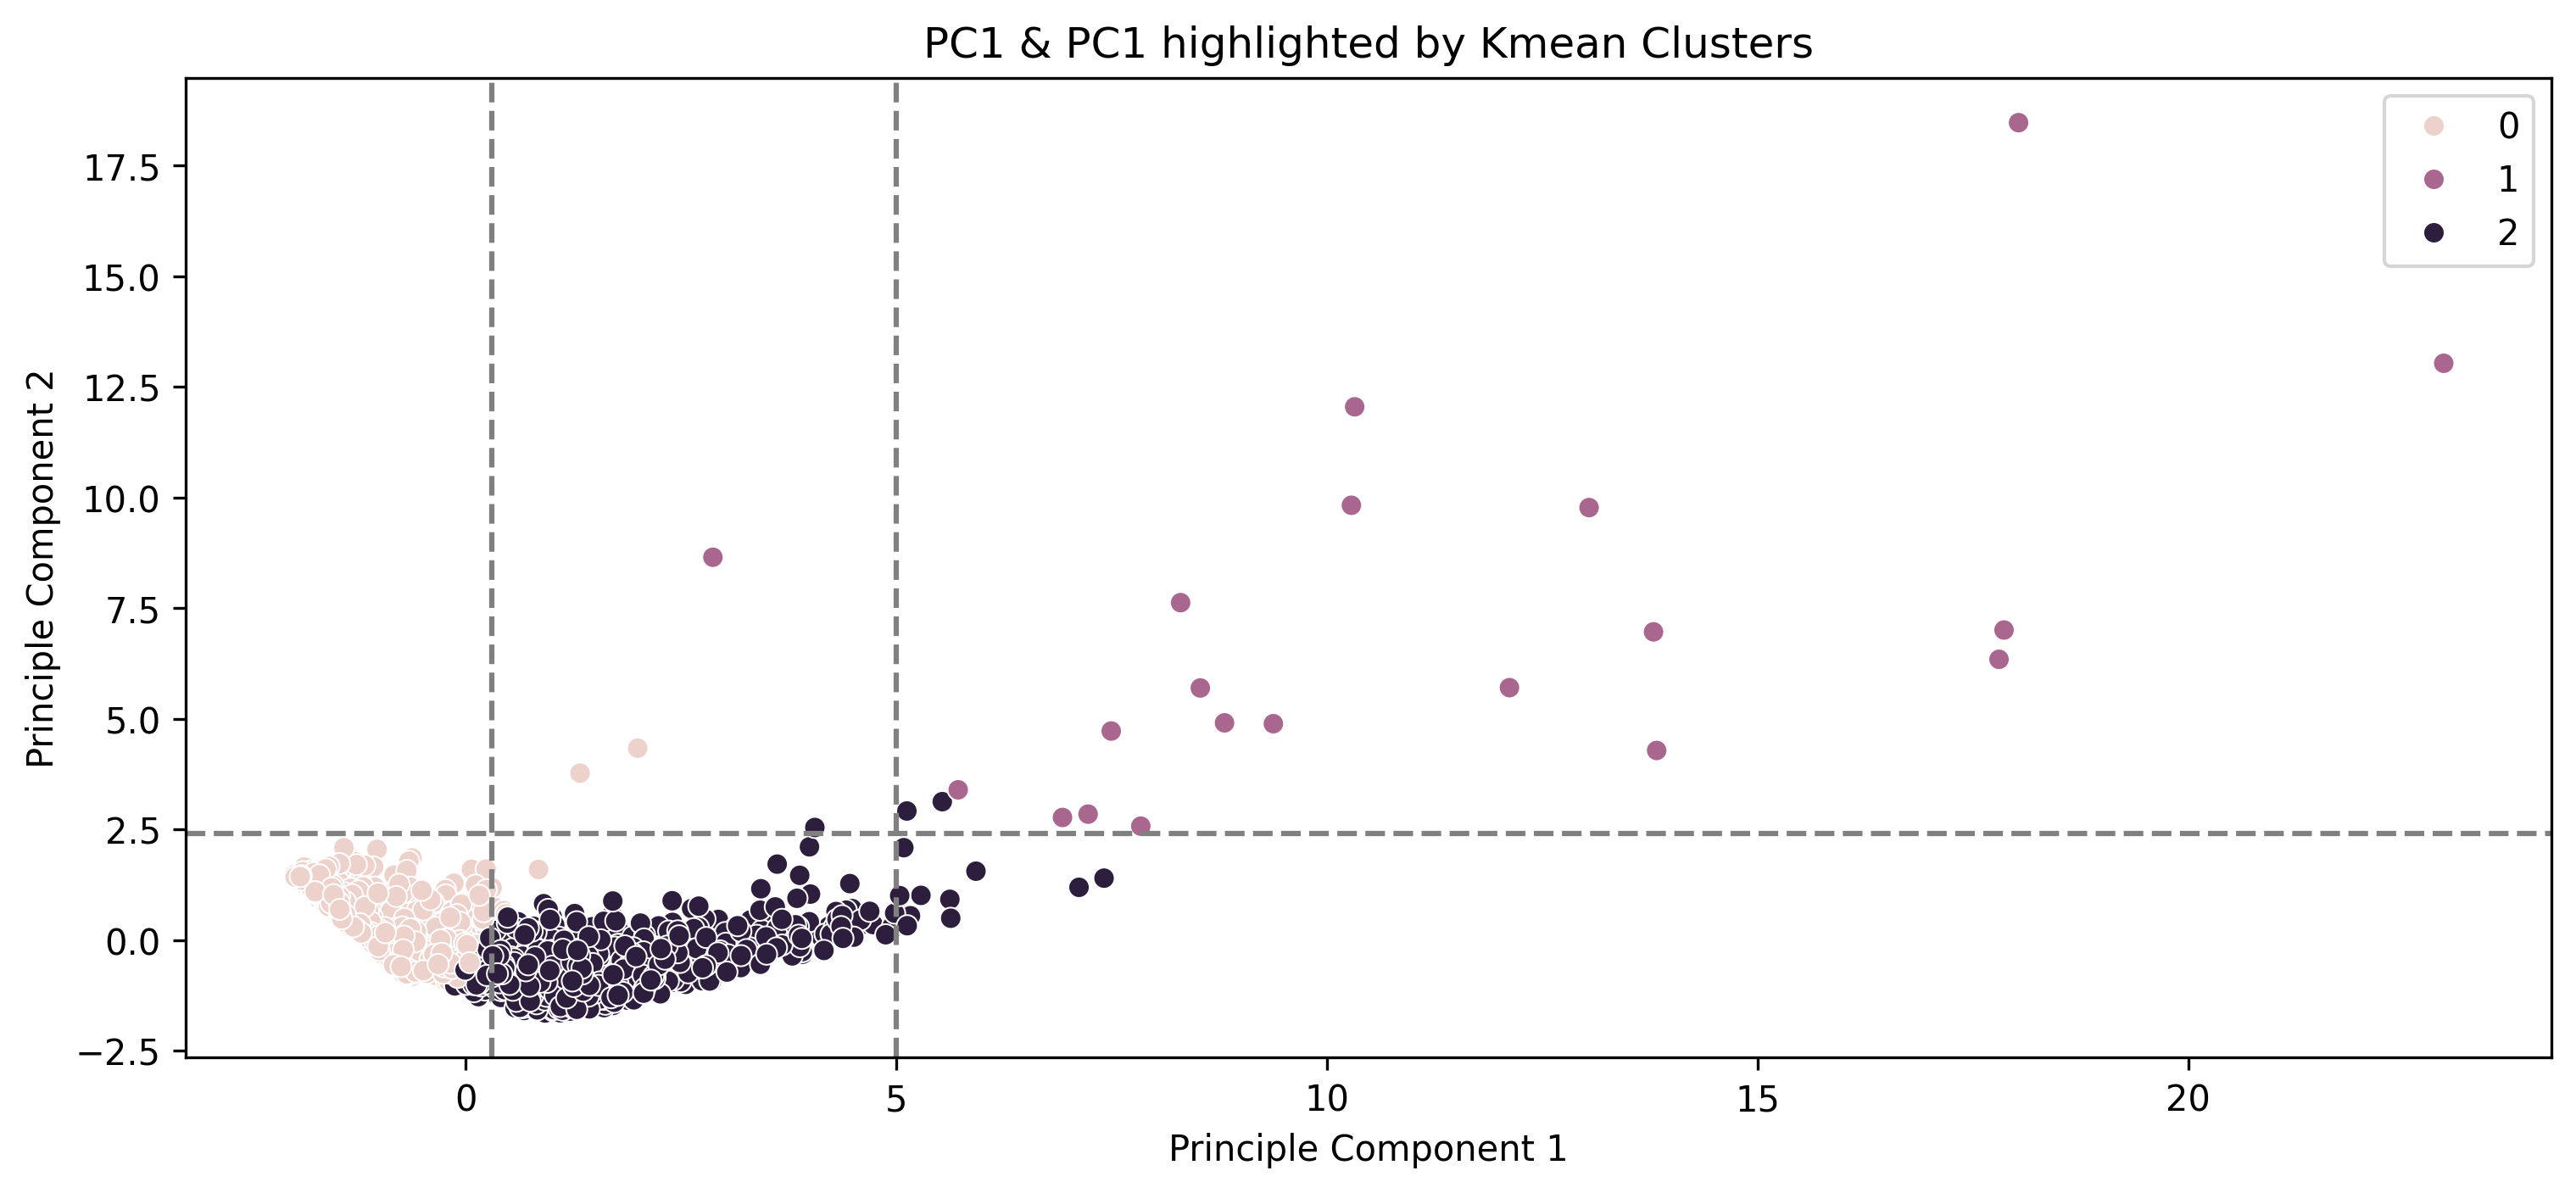

In [162]:
ideal_clusters = 3

kmeans = KMeans(n_clusters = ideal_clusters, random_state = 42, n_init = 10)
k_labels = kmeans.fit_predict(X_pca)


pc1 = X_pca[:,0]
pc2 = X_pca[:,1]

plt.figure(figsize = (12,5), dpi = 300)
sns.scatterplot(x = pc1, y = pc2, hue = k_labels)
plt.title("PC1 & PC1 highlighted by Kmean Clusters")
plt.axhline(y = 2.4, color = "grey", linestyle = '--')
plt.axvline(x = 0.3, color = "grey", linestyle = '--')
plt.axvline(x = 5, color = "grey", linestyle = '--')
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.show()

In [163]:
# Adding clusters view to Database
klabels_df = pd.DataFrame(df["CustomerID"])

klabels_df['KSegment'] = k_labels

with engine.begin() as conn:
    conn.execute(text('DROP TABLE IF EXISTS customer_segment_labels CASCADE'))
klabels_df.to_sql(
    name = "customer_segment_labels",
    con = engine,
    if_exists = "replace",
    index = False
)
print("Successfully created/updated customer_segment_lables table")

query = """
CREATE OR REPLACE VIEW v_segmented_data AS
SELECT "CustomerID",
    "CohortMonth",
    "Recency",
    "Frequency",
    "TotalRevenue",
    "Tenure",
    "ProductDiversity",
    "R" AS "R_Score",
    "M" AS "M_Score",
    "F" AS "F_Score",
    "RfmScore",
    "KSegment"
FROM v_customer_metrics
LEFT JOIN (SELECT *
          FROM v_customer_rfm)
USING("CustomerID")
LEFT JOIN customer_segment_labels
USING("CustomerID")
"""

with engine.begin() as conn:
    conn.execute(text(query))
    print("Successfully created/updated v_segmented_data view")

print("\nData Preview of v_segmented_data view:")

df = pd.read_sql(text('SELECT * FROM v_segmented_data'), con = engine)
df.head()

Successfully created/updated customer_segment_lables table
Successfully created/updated v_segmented_data view

Data Preview of v_segmented_data view:


,CustomerID,CohortMonth,Recency,Frequency,TotalRevenue,Tenure,ProductDiversity,R_Score,M_Score,F_Score,RfmScore,KSegment
0,12346.0,2011-01,325,1,77183.60,0,1,1,5,1,7,1
1,12347.0,2010-12,129,5,2790.86,238,82,5,5,5,15,2
2,12348.0,2010-12,248,3,1487.24,110,22,2,4,4,10,0
3,12350.0,2011-02,310,1,334.40,0,17,1,2,2,5,0
4,12352.0,2011-02,262,4,1561.81,34,26,3,5,5,13,0


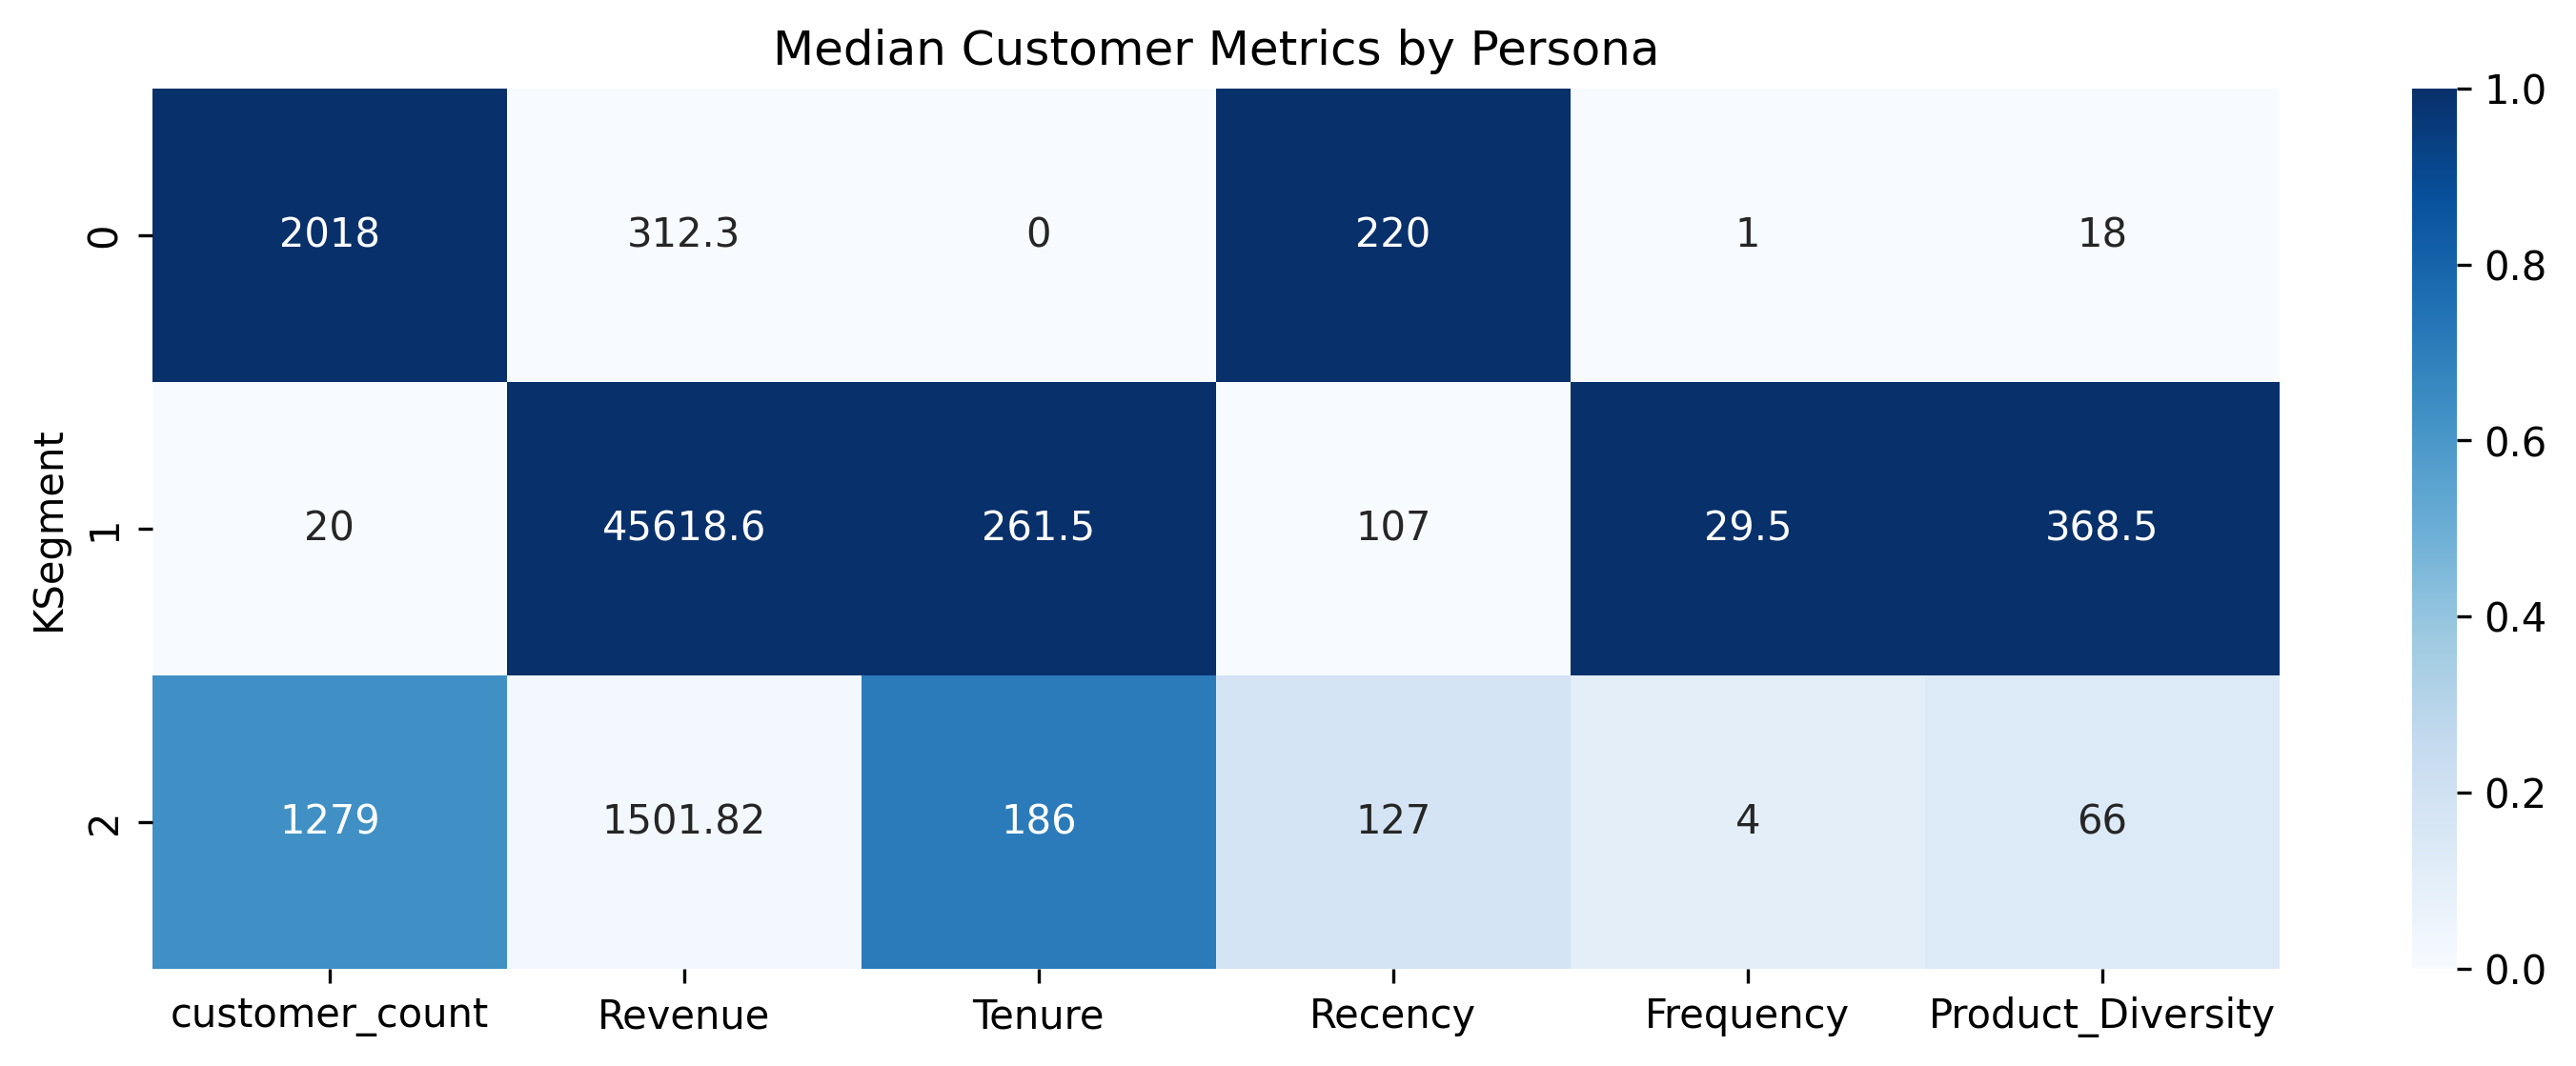

In [164]:
medians = df.groupby("KSegment").agg(
  customer_count = ("CustomerID", "count"),
  Revenue = ("TotalRevenue", "median"),
  Tenure = ("Tenure", "median"),
  Recency = ("Recency", "median"),
  Frequency = ("Frequency", "median"),
  Product_Diversity = ("ProductDiversity", "median"))

#medians = df.groupby("KSegment")[['Frequency', 'Recency', 'TotalRevenue', 'Tenure', 'ProductDiversity']].median()
medians_norm = (medians - medians.min())/(medians.max() - medians.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = medians_norm, annot = medians, fmt = 'g', cmap = 'Blues')
plt.title('Median Customer Metrics by Persona')
plt.show()

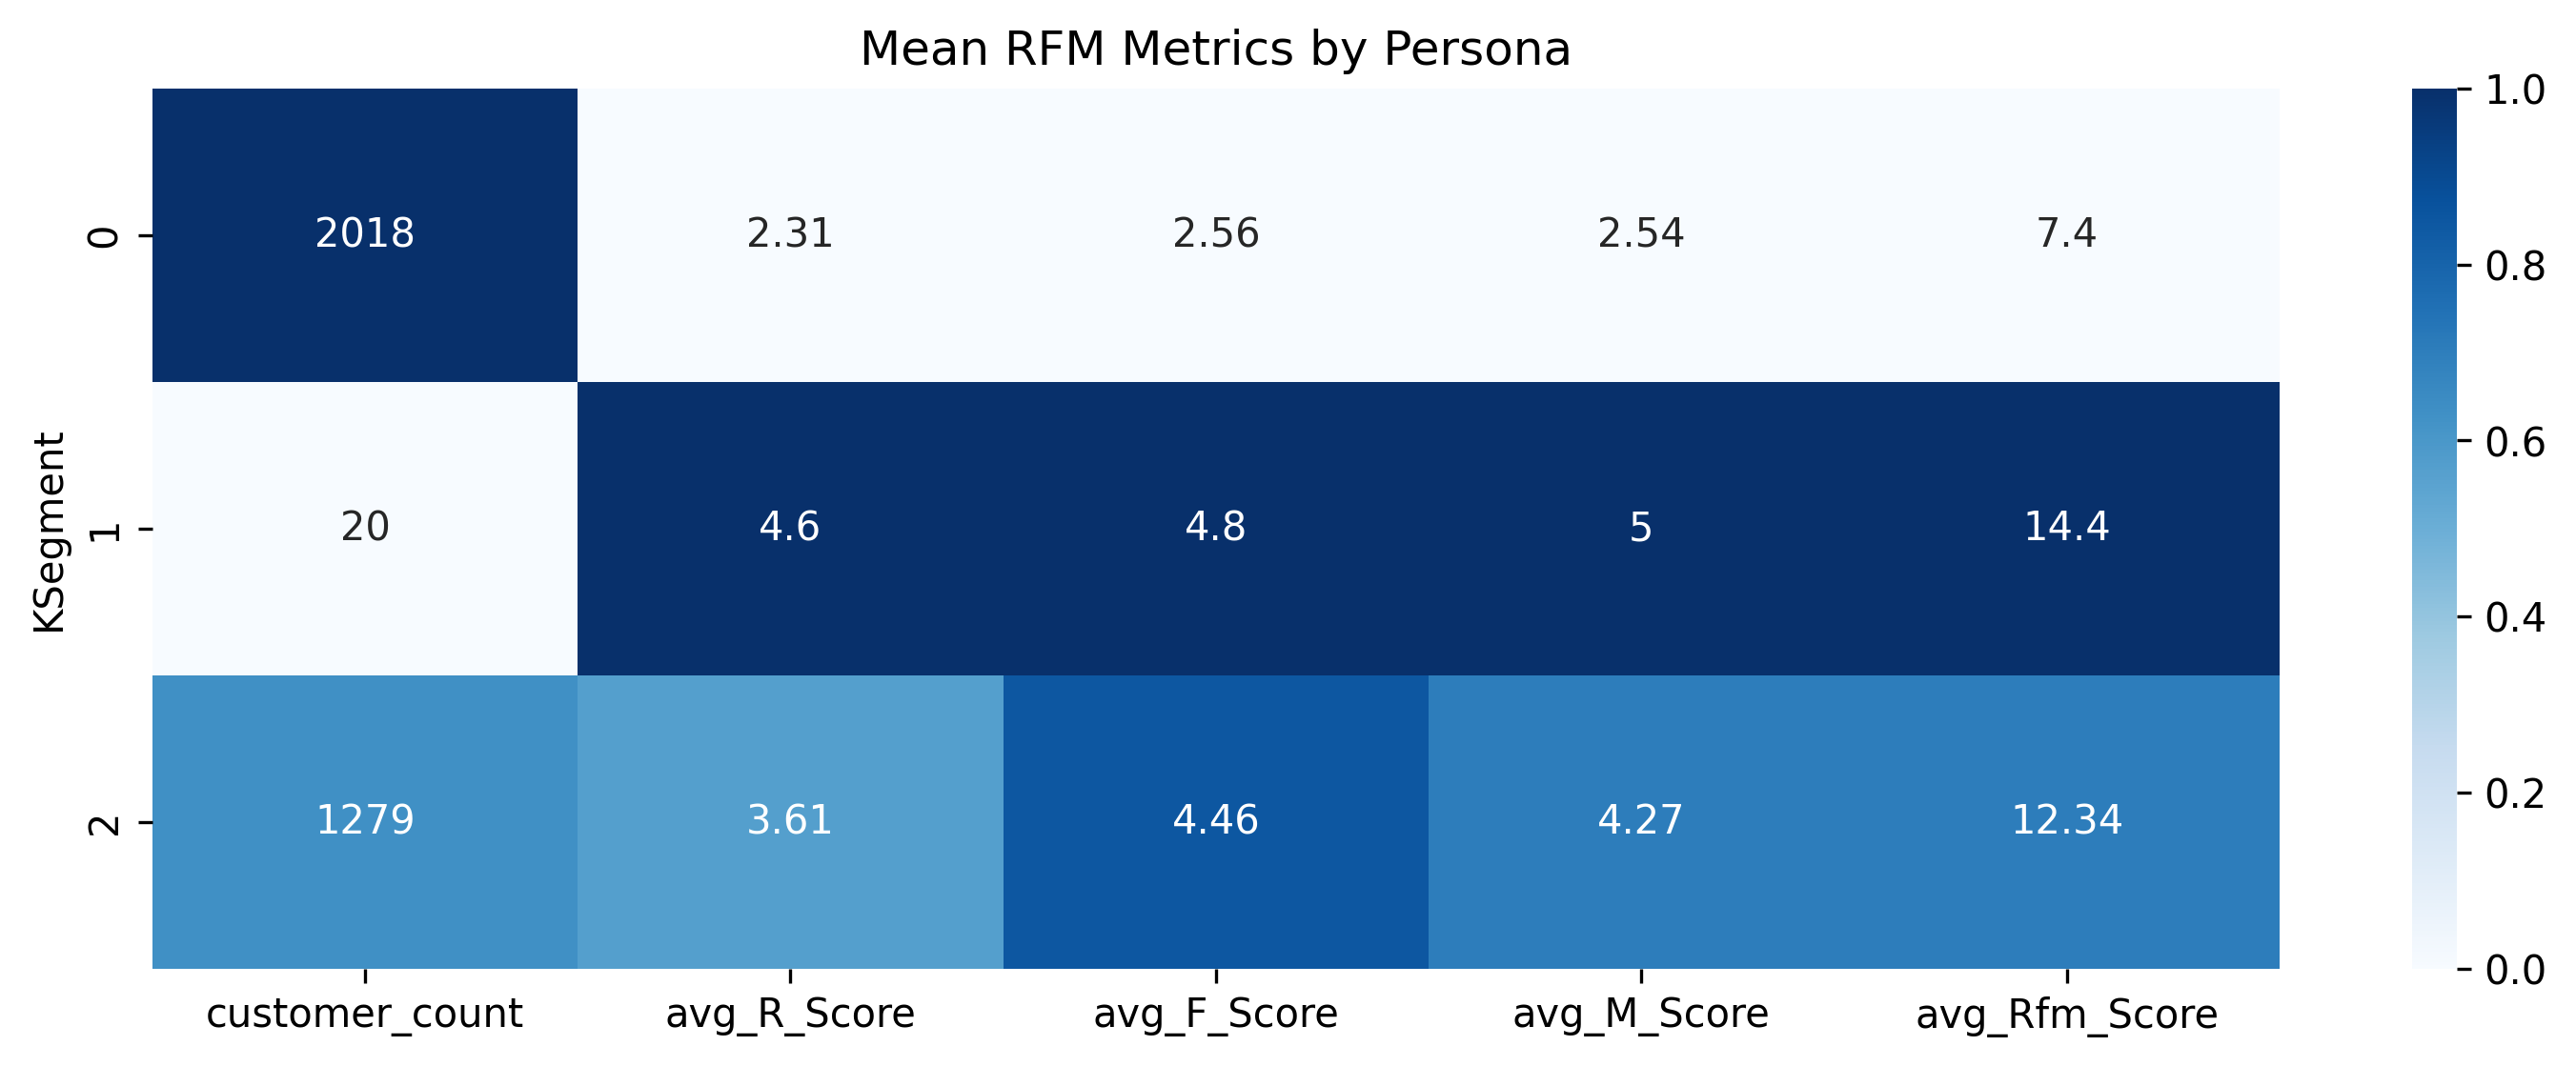

In [165]:
means = df.groupby("KSegment").agg(
  customer_count = ("CustomerID", "count"),
  avg_R_Score = ("R_Score", "mean"),
  avg_F_Score = ("F_Score", "mean"),
  avg_M_Score = ("M_Score", "mean"),
  avg_Rfm_Score= ("RfmScore", "mean")).round(2)

means_norm = (means - means.min())/(means.max() - means.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = means_norm, annot = means, fmt = 'g', cmap = 'Blues')
#plt.ylabel("KSegments")
plt.title('Mean RFM Metrics by Persona')
plt.show()

In [166]:
# Mapping defined segments to Database

query = """
ALTER TABLE customer_segment_labels
ADD COLUMN "Persona" VARCHAR(50);

UPDATE customer_segment_labels
SET "Persona" = CASE
     WHEN "KSegment" = 0 THEN 'One-Time Acquaintances'
     WHEN "KSegment" = 1 THEN 'High-Value Elite'
     WHEN "KSegment" = 2 THEN 'Loyal Steady Shoppers'
     ELSE 'Not_assigned'
END

"""

with engine.begin() as conn:
    conn.execute(text(query))
print("Assigned Customer Persona to Kmean labels in v_customer_segment_labels Postgres View")

persona_mapping = {
    0: "One-Time Acquaintances",
    1: "High-Value Elite",
    2: "Loyal Steady Shoppers"
}

df['Persona'] = df['KSegment'].map(persona_mapping)

Assigned Customer Persona to Kmean labels in v_customer_segment_labels Postgres View


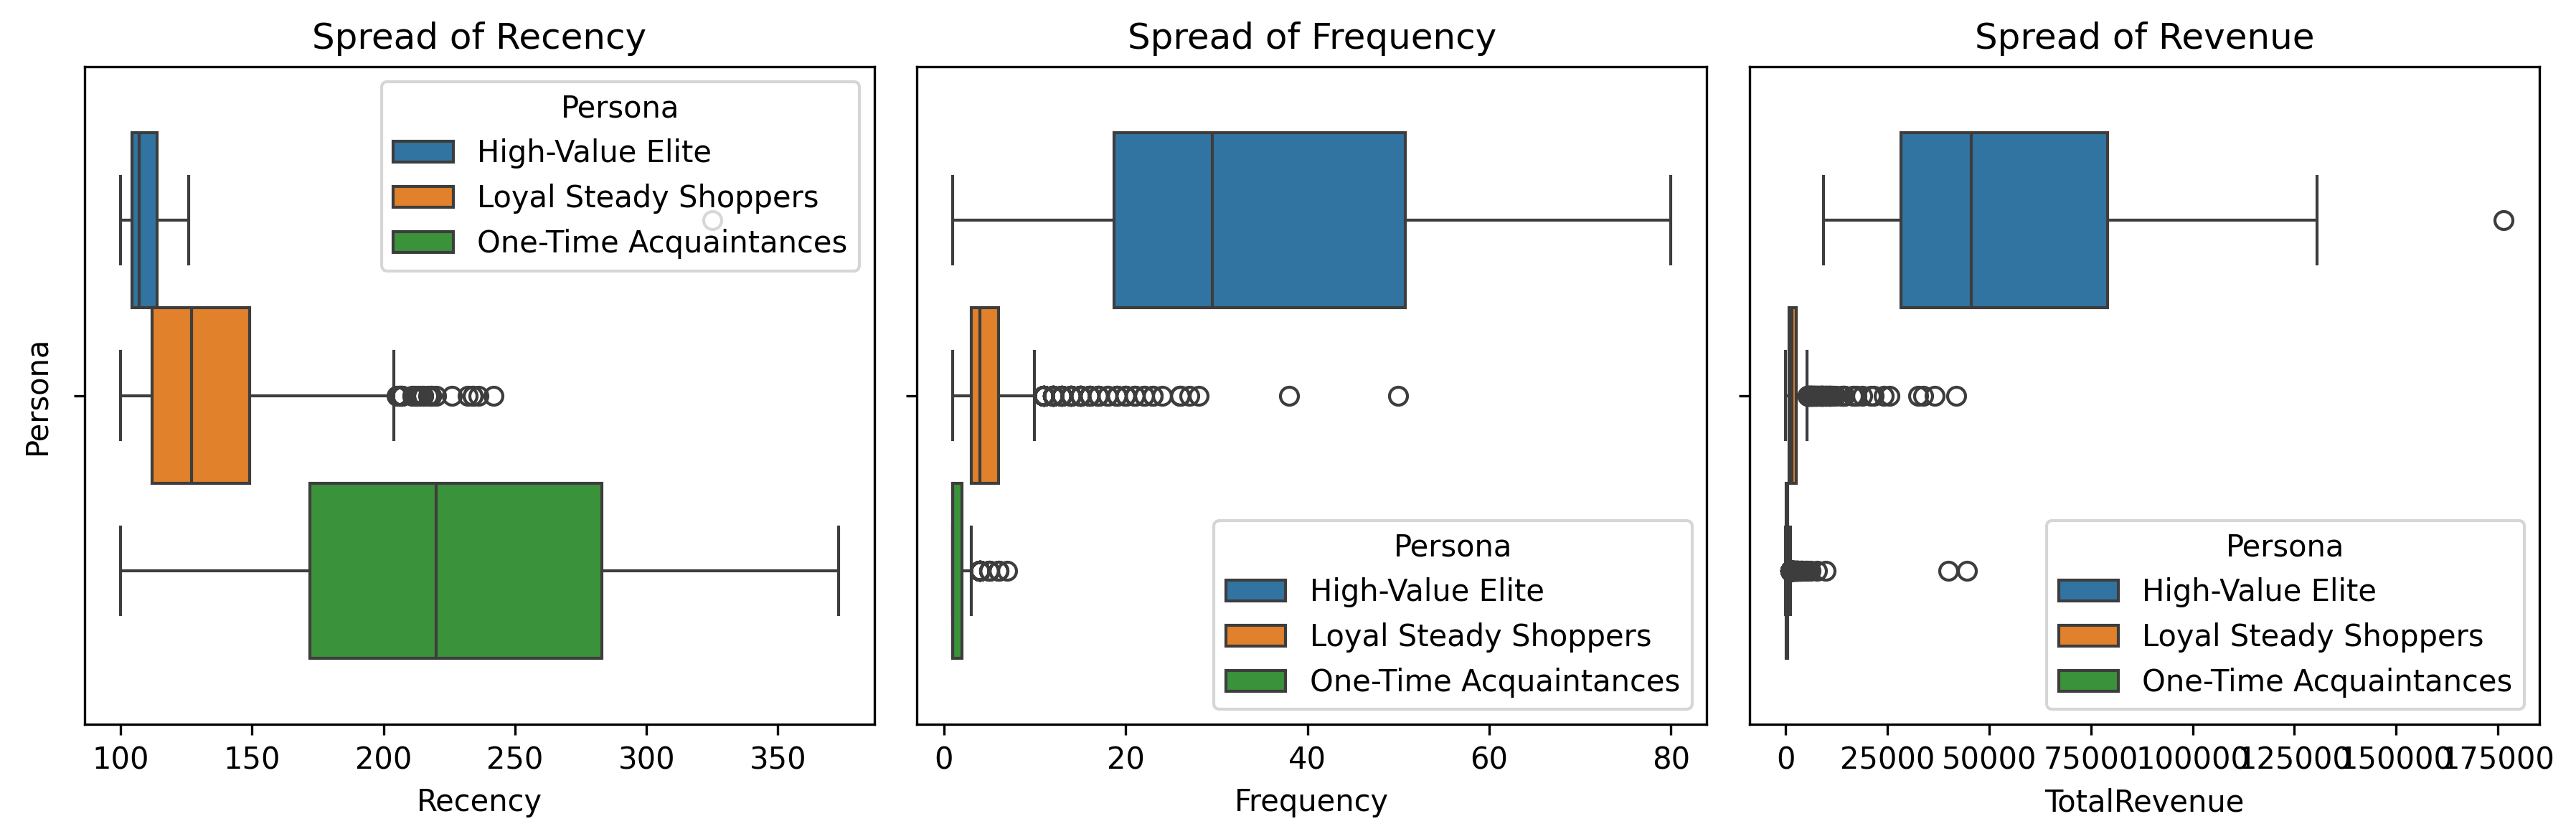

In [167]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.boxplot(data = df, x = "Recency", hue = "Persona", ax = ax1)
ax1.set_title("Spread of Recency")
ax1.set_ylabel("Persona")

sns.boxplot(data = df, x = "Frequency", hue = "Persona", ax = ax2)
ax2.set_title("Spread of Frequency")
ax1.set_ylabel("Persona")

sns.boxplot(data = df, x = "TotalRevenue", hue = "Persona", ax = ax3)
ax3.set_title("Spread of Revenue")
ax1.set_ylabel("Persona")

plt.tight_layout()
plt.show()

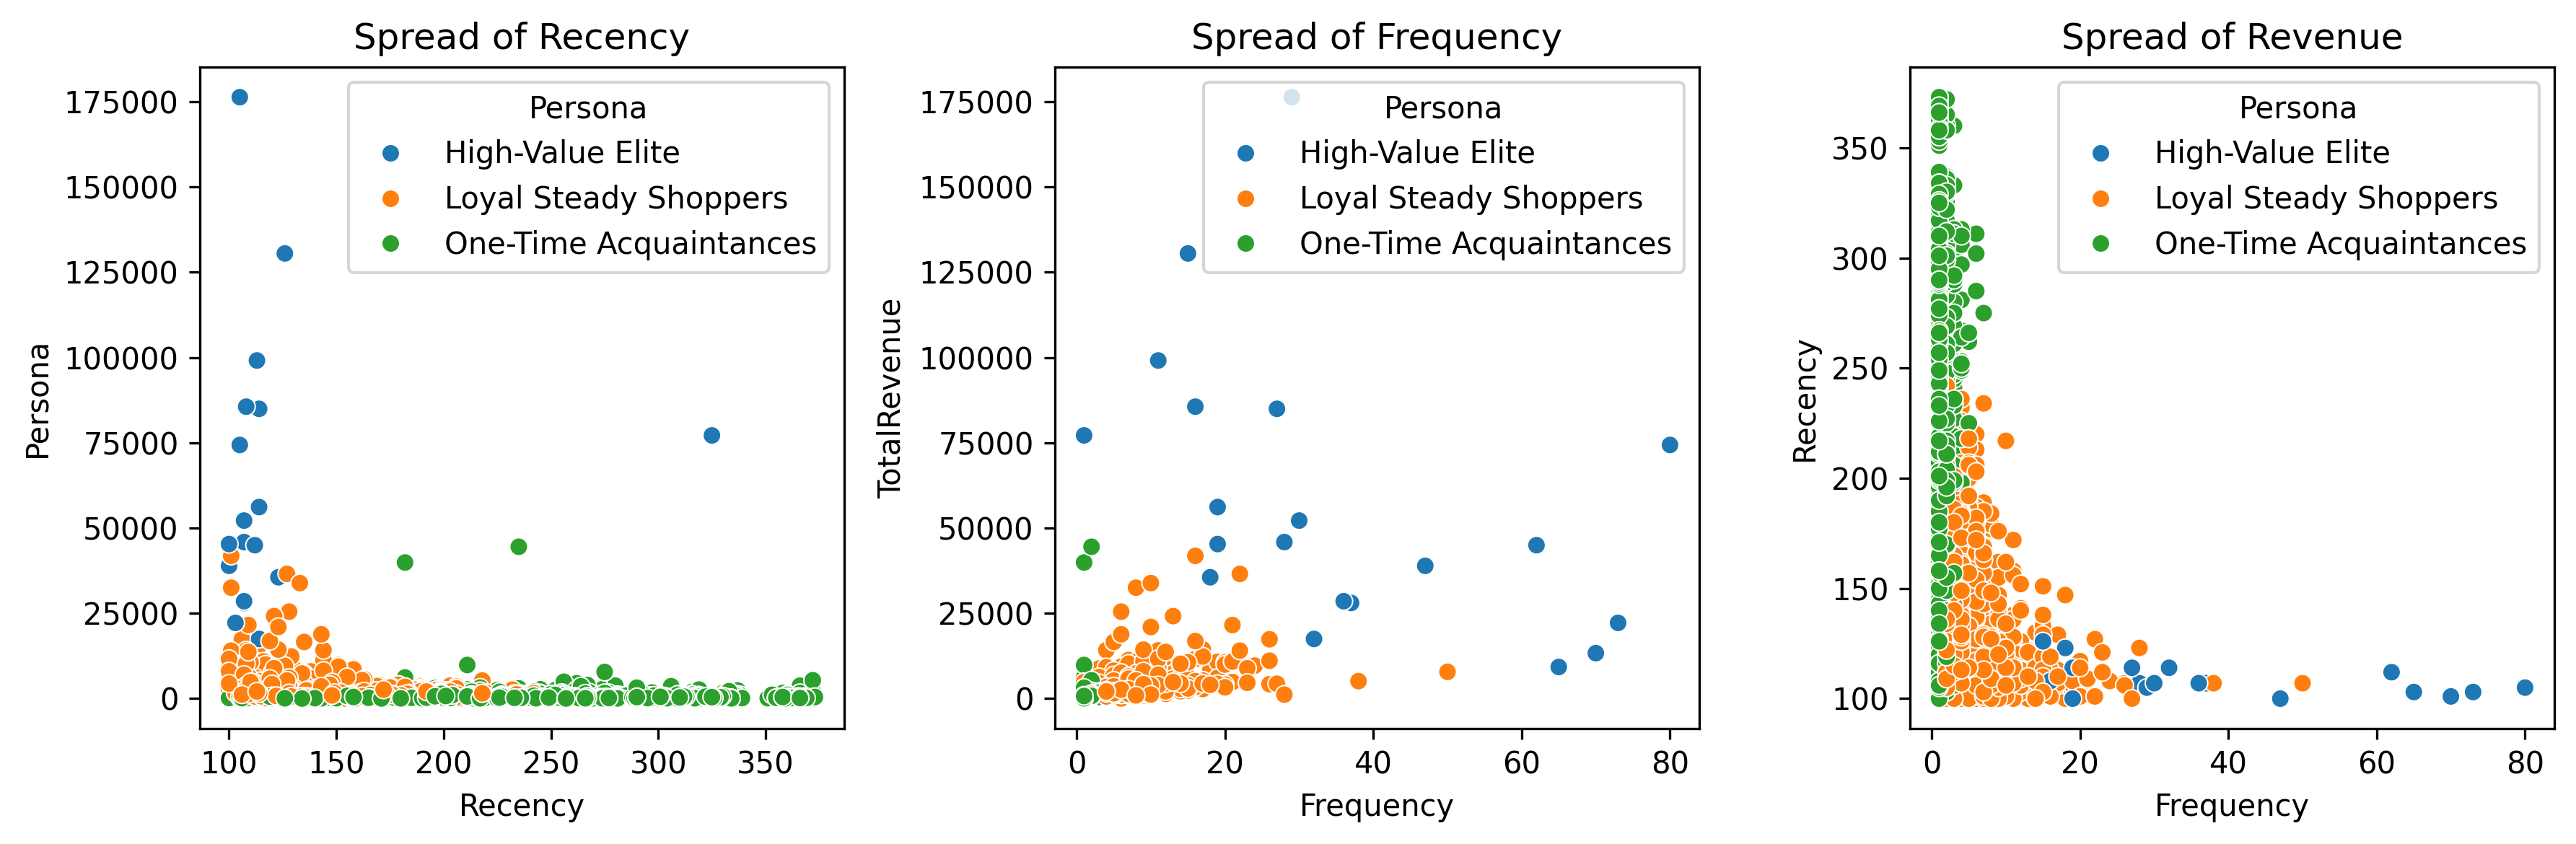

In [168]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.scatterplot(data = df, x = "Recency", y = "TotalRevenue", hue = "Persona", ax = ax1)
ax1.set_title("Spread of Recency")
ax1.set_ylabel("Persona")

sns.scatterplot(data = df, x = "Frequency", y = "TotalRevenue", hue = "Persona", ax = ax2)
ax2.set_title("Spread of Frequency")
ax1.set_ylabel("Persona")

sns.scatterplot(data = df, x = "Frequency", y = "Recency" , hue = "Persona", ax = ax3)
ax3.set_title("Spread of Revenue")
ax1.set_ylabel("Persona")

plt.tight_layout()
plt.show()

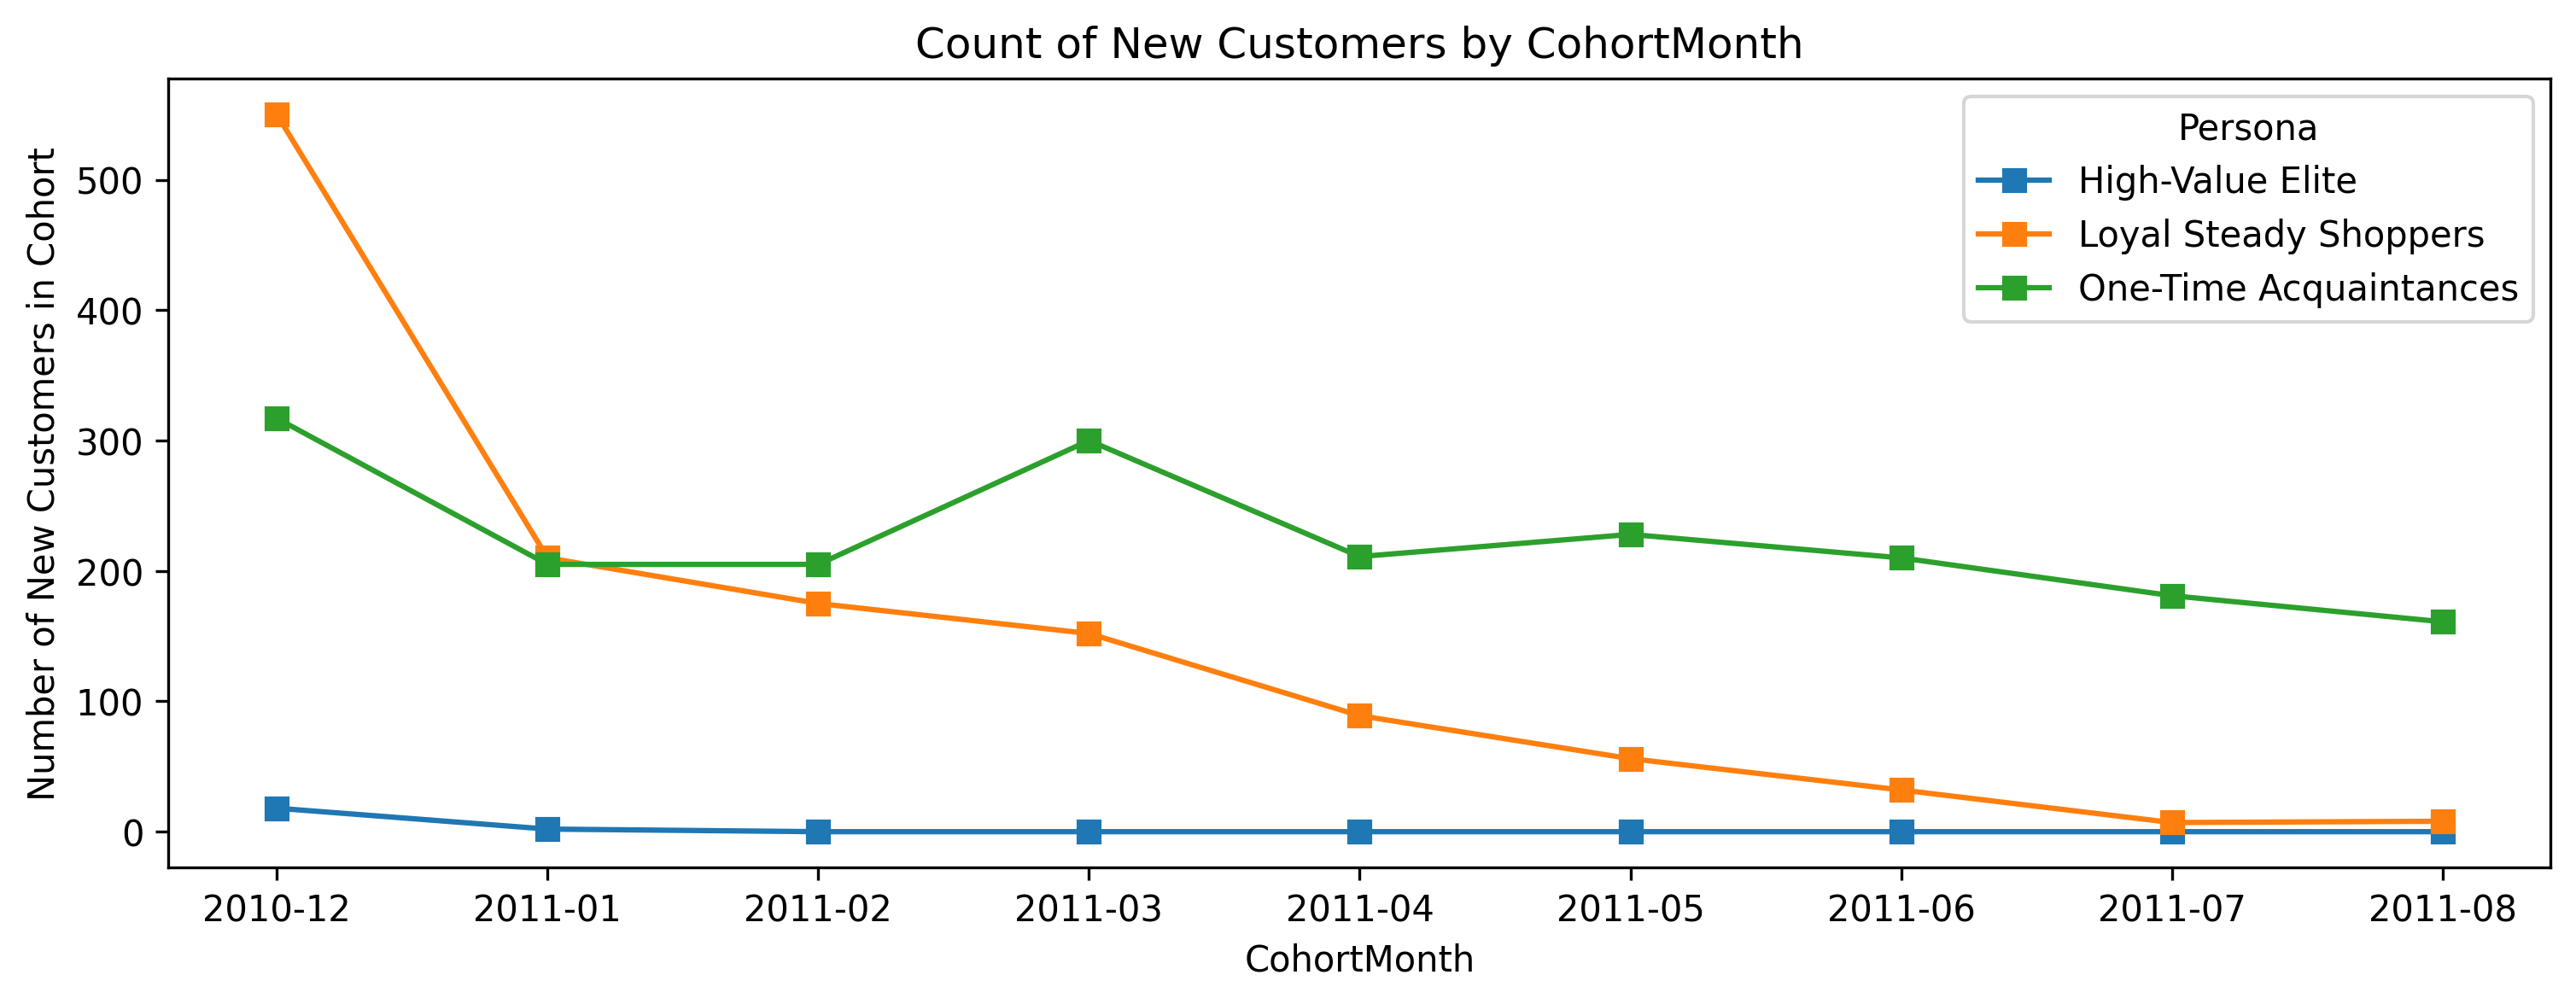

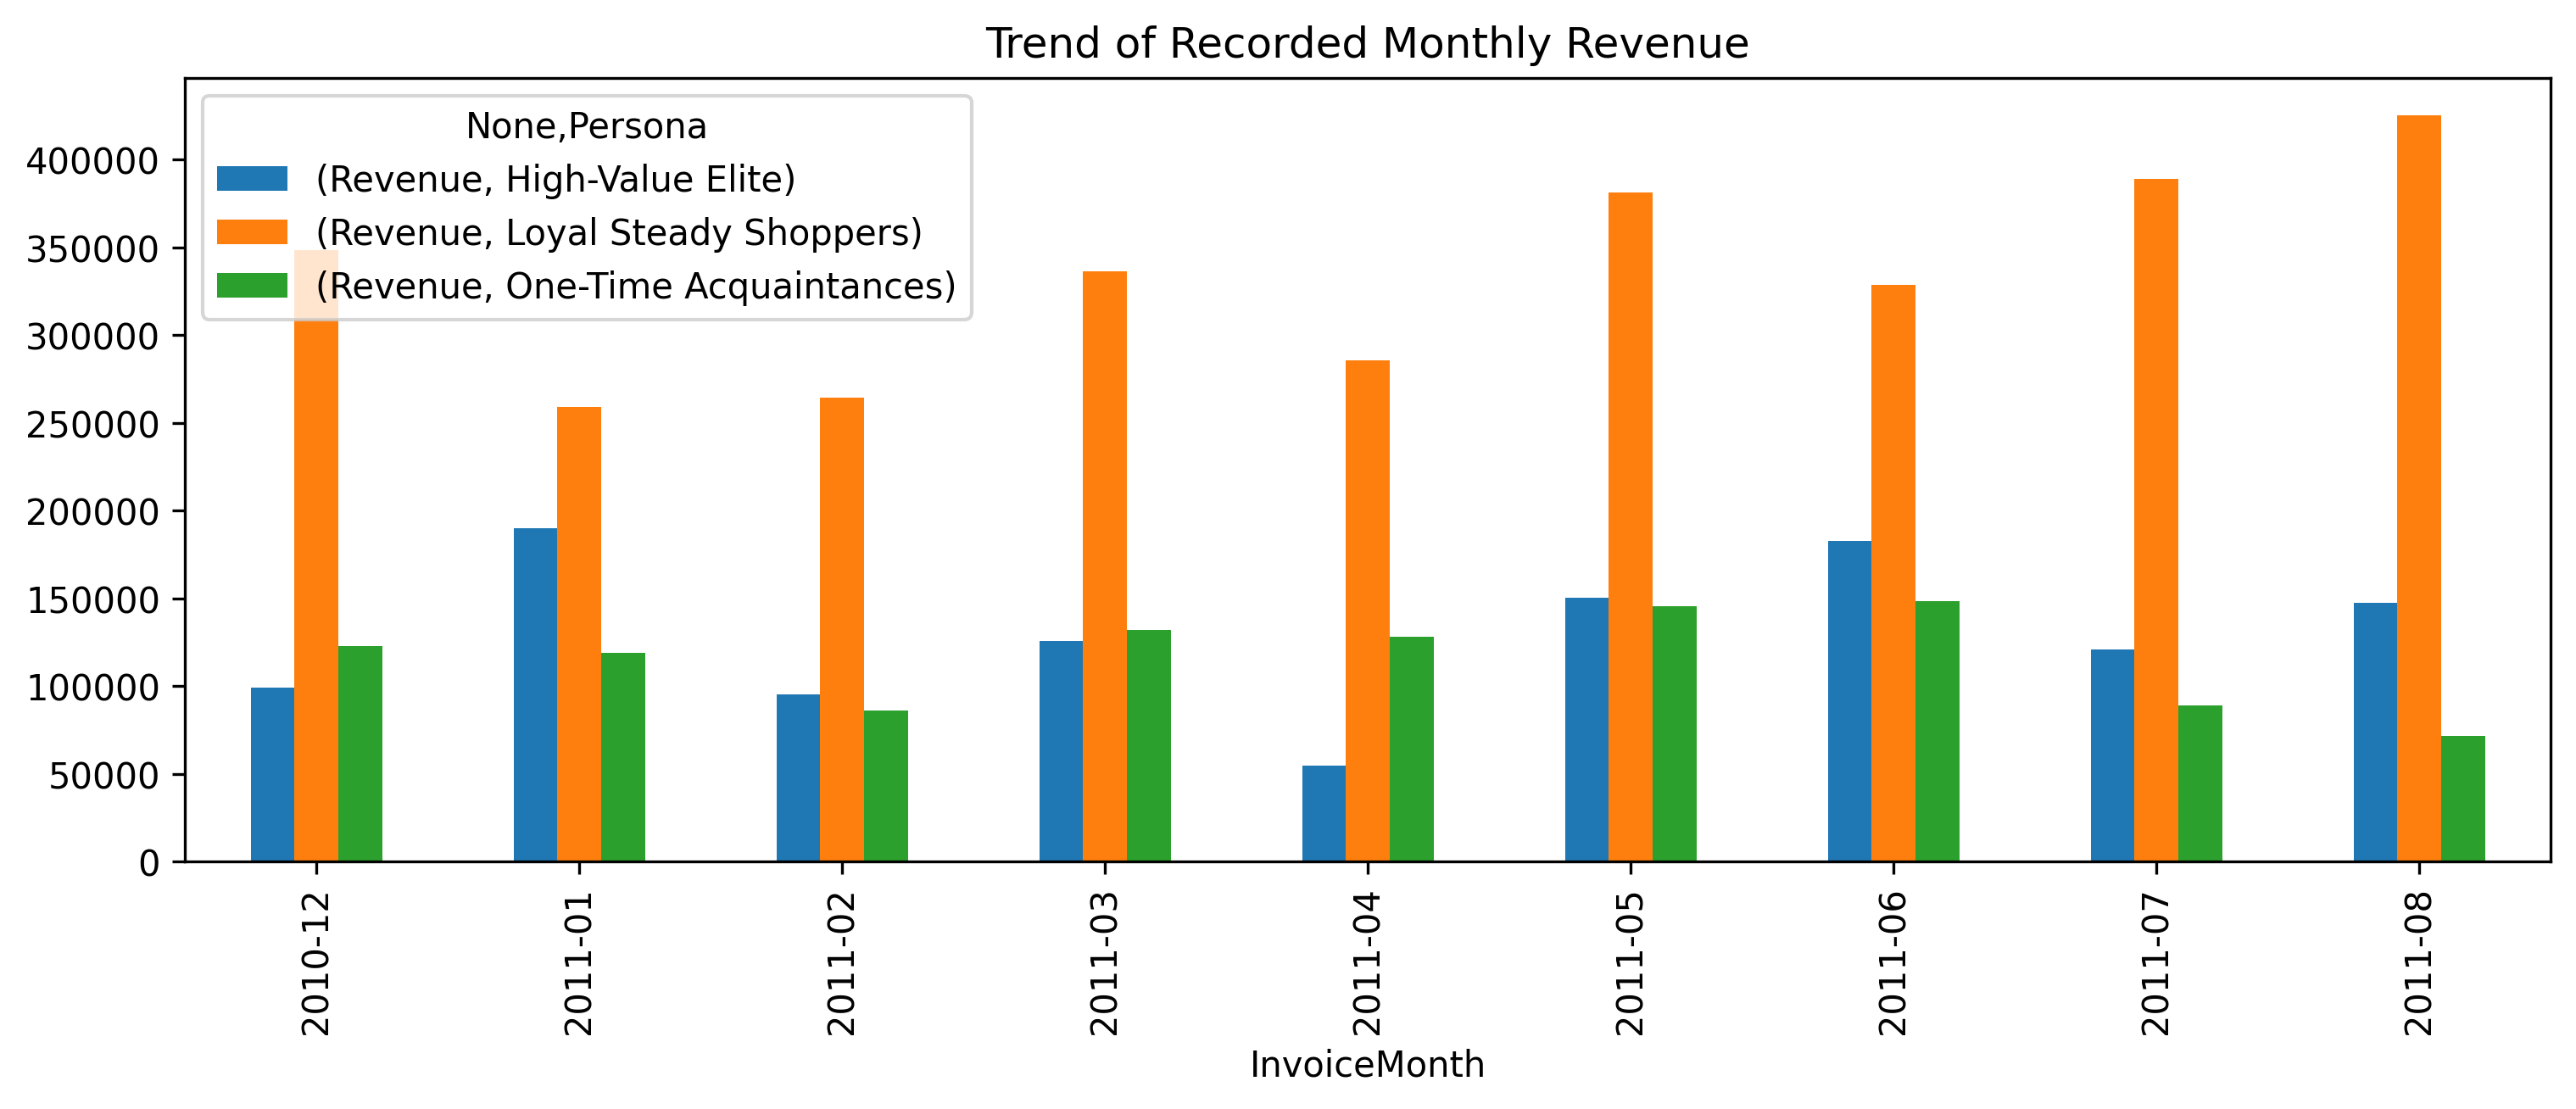


Number New Client by CohortMonth


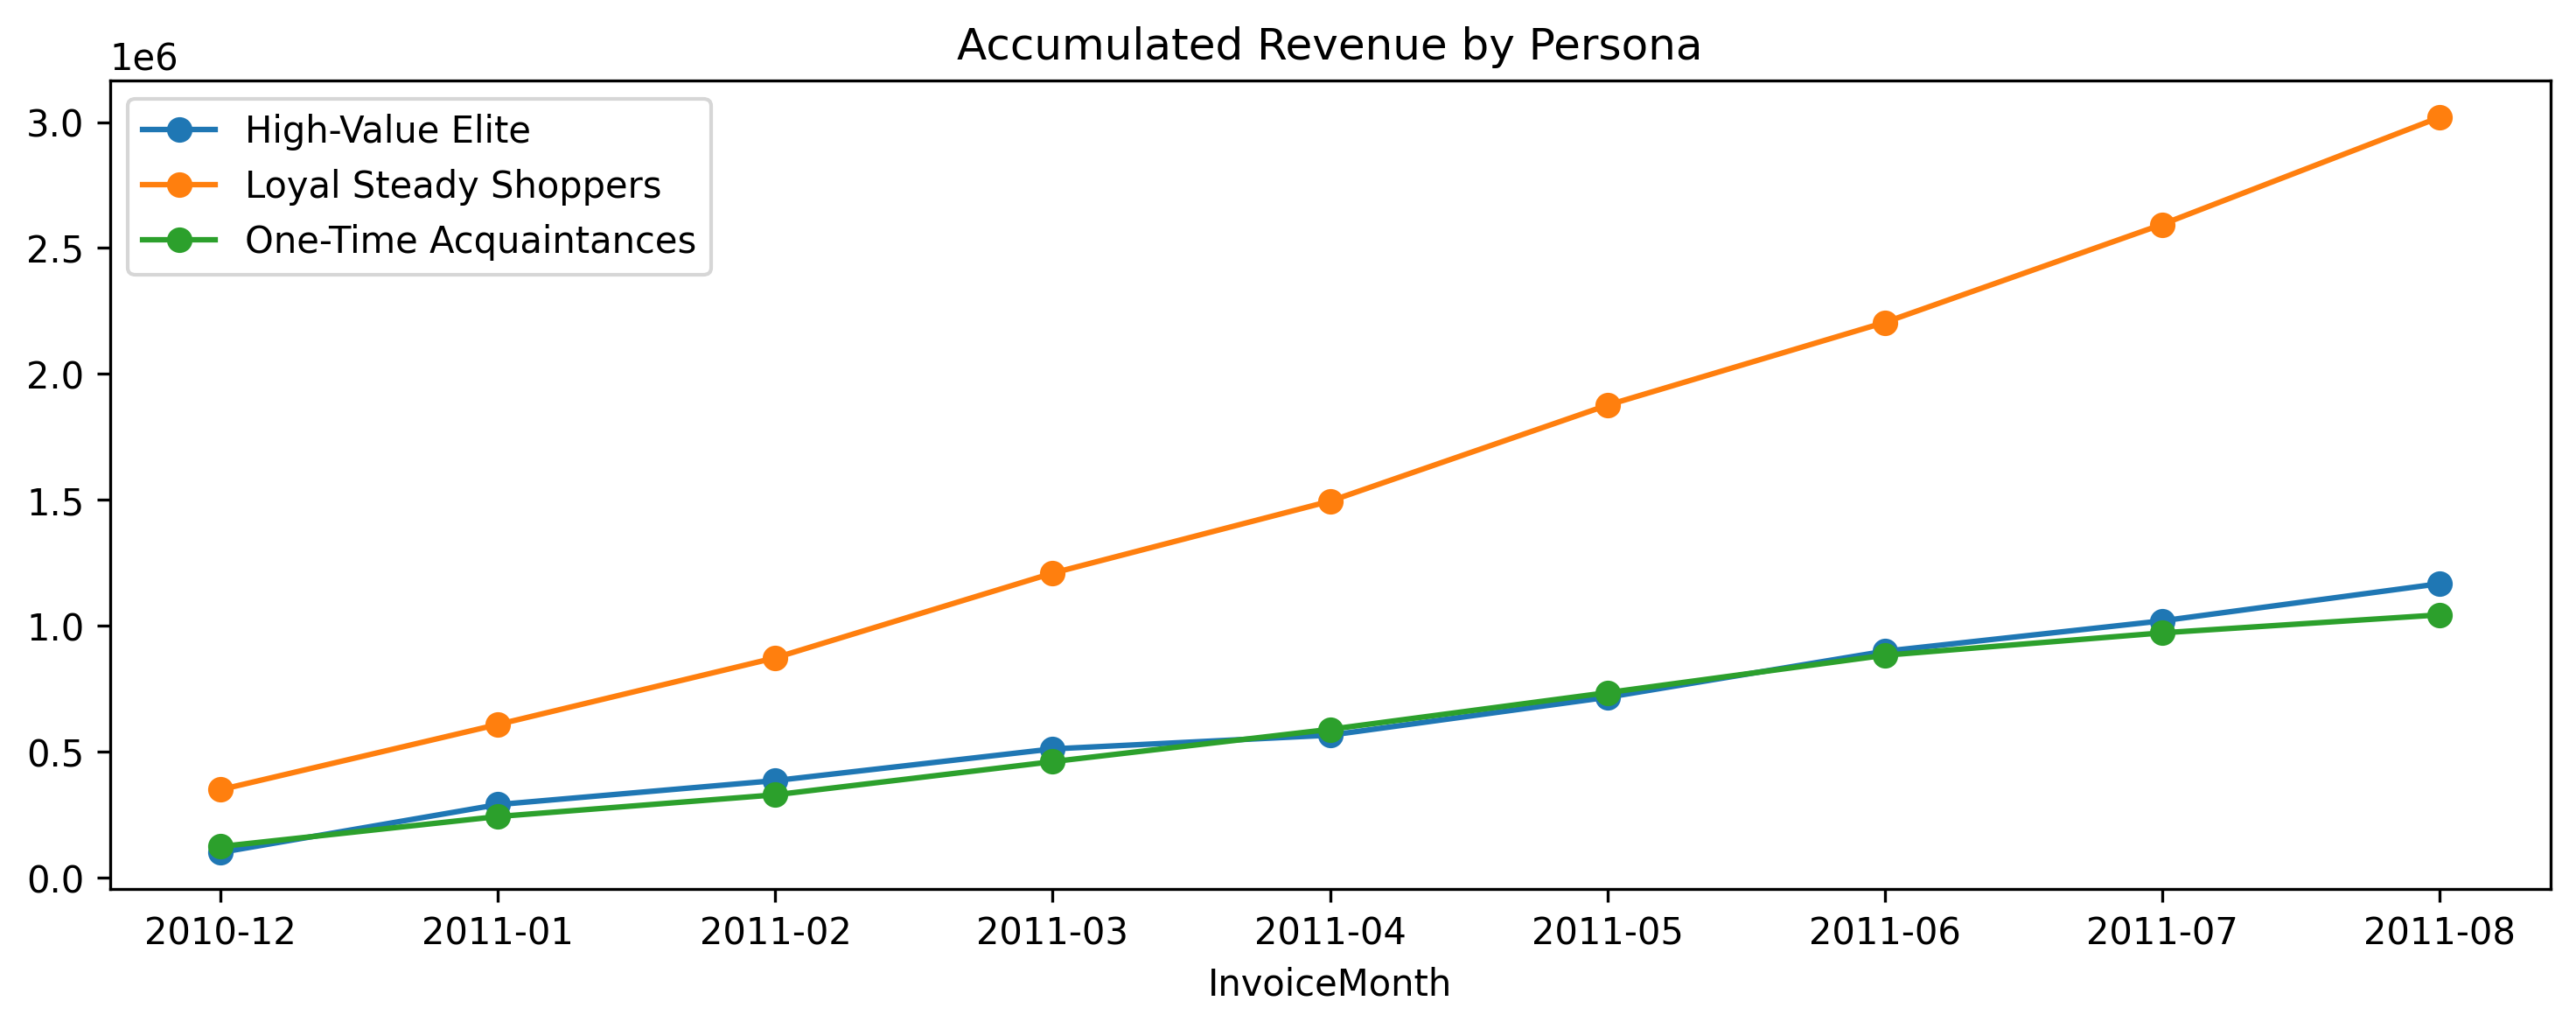

In [199]:
crosstab_persona  = pd.crosstab(df["CohortMonth"], df["Persona"])

crosstab_norm = (crosstab_persona - crosstab_persona.min())/(crosstab_persona.max() - crosstab_persona.min())

fig, ax = plt.subplots(1,1,figsize = (12,4), dpi = 300)
crosstab_persona.plot(kind = "line", marker = 's', ax = ax)
#sns.heatmap(data = crosstab_norm,annot = crosstab_persona, ax = ax, fmt = 'g', cmap = "Blues")
ax.set_ylabel("Number of New Customers in Cohort")
plt.title("Count of New Customers by CohortMonth")
plt.show()

query = """
WITH data AS
(SELECT "CustomerID",
    "Persona",
     TO_CHAR("InvoiceDate", 'YYYY-MM') AS "InvoiceMonth",
    "Revenue"
FROM v_clean_sales_analytics
LEFT JOIN customer_segment_labels
USING("CustomerID")
WHERE "InvoiceDate" <= '2011-08-31')

SELECT "InvoiceMonth",
    "Persona",
    SUM("Revenue") AS "Revenue"
FROM data
GROUP BY 1,2
"""


rev_df = pd.read_sql(text(query), con = engine).set_index(["InvoiceMonth", "Persona"]).unstack()

fig, ax = plt.subplots(1,1, figsize = (12,4), dpi = 300)
rev_df.plot(kind = "bar", ax = ax)
ax.set_title("Trend of Recorded Monthly Revenue")

plt.show()

print("\nNumber New Client by CohortMonth")
crosstab_persona.transpose()

accum = pd.DataFrame(rev_df["Revenue"]["High-Value Elite"].cumsum())
accum["Loyal Steady Shoppers"] = rev_df["Revenue"]["Loyal Steady Shoppers"].cumsum()
accum["One-Time Acquaintances"] = rev_df["Revenue"]["One-Time Acquaintances"].cumsum()

fig, ax = plt.subplots(1,1, figsize = (12,4), dpi = 300)
accum.plot(kind = "line", marker = 'o', ax = ax)
ax.set_title("Accumulated Revenue by Persona")
plt.show()